# Google Play Store Analysis

## Project Overview

This project analyzes Google Play Store applications and user reviews
to understand app categories, ratings, installations, pricing,
user engagement, and sentiment.

## Objectives

1. Understand the structure of Google Play Store applications.
2. Clean missing and incorrect data.
3. Analyze app categories.
4. Analyze ratings and reviews.
5. Study installations and app size.
6. Compare free and paid applications.
7. Analyze app pricing.
8. Analyze user sentiment.
9. Identify business insights and trends.
10. Generate recommendations based on the analysis.

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook
- Sentiment Analysis

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
apps = pd.read_csv(
    "googleplaystore.csv"
)

reviews = pd.read_csv(
    "googleplaystore_user_reviews.csv"
)

print("Apps dataset loaded successfully!")
print("Reviews dataset loaded successfully!")

Apps dataset loaded successfully!
Reviews dataset loaded successfully!


Check Dataset Size

In [5]:
print("Apps Dataset Shape:", apps.shape)
print("Reviews Dataset Shape:", reviews.shape)

Apps Dataset Shape: (10841, 13)
Reviews Dataset Shape: (64295, 5)


Display First 5 Rows

In [6]:
print("Google Play Store Apps:")
display(apps.head())

Google Play Store Apps:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
print("User Reviews:")
display(reviews.head())

User Reviews:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


Check Columns Name

In [8]:
print("Apps Columns:")
print(apps.columns.tolist())

print("\nReviews Columns:")
print(reviews.columns.tolist())

Apps Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Reviews Columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


Data Information

In [9]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [10]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


Check Missing Value

In [11]:
print("Missing values in Apps dataset:")
print(apps.isnull().sum())

Missing values in Apps dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [12]:
print("Missing values in Reviews dataset:")
print(reviews.isnull().sum())

Missing values in Reviews dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [13]:
missing_percentage = (
    apps.isnull().sum() / len(apps) * 100
).sort_values(ascending=False)

print(missing_percentage)

Rating            13.596532
Current Ver        0.073794
Android Ver        0.027673
Type               0.009224
Content Rating     0.009224
App                0.000000
Category           0.000000
Reviews            0.000000
Size               0.000000
Installs           0.000000
Price              0.000000
Genres             0.000000
Last Updated       0.000000
dtype: float64


Check Duplicate Rows

In [14]:
print("Duplicate rows in Apps:", apps.duplicated().sum())
print("Duplicate rows in Reviews:", reviews.duplicated().sum())

Duplicate rows in Apps: 483
Duplicate rows in Reviews: 33616


Remove Duplicate App Records

In [15]:
apps['App'].duplicated().sum()

np.int64(1181)

In [16]:
apps['Reviews'] = pd.to_numeric(
    apps['Reviews'],
    errors='coerce'
)

apps = apps.sort_values(
    by='Reviews',
    ascending=False
)

apps = apps.drop_duplicates(
    subset='App',
    keep='first'
)

apps = apps.reset_index(drop=True)

print("Dataset shape after removing duplicate apps:")
print(apps.shape)

Dataset shape after removing duplicate apps:
(9660, 13)


Clean Reviews Column

In [17]:
apps['Reviews'] = pd.to_numeric(
    apps['Reviews'],
    errors='coerce'
)

print(apps['Reviews'].dtype)

float64


In [18]:
print(apps['Reviews'].describe())

count    9.659000e+03
mean     2.168041e+05
std      1.831430e+06
min      0.000000e+00
25%      2.500000e+01
50%      9.690000e+02
75%      2.945350e+04
max      7.815831e+07
Name: Reviews, dtype: float64


Clean Installs Column

In [19]:
apps['Installs'] = (
    apps['Installs']
    .astype(str)
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
)

apps['Installs'] = pd.to_numeric(
    apps['Installs'],
    errors='coerce'
)

print(apps['Installs'].head())
print(apps['Installs'].dtype)

0    1.000000e+09
1    1.000000e+09
2    1.000000e+09
3    1.000000e+09
4    1.000000e+08
Name: Installs, dtype: float64
float64


Clean Price Column

In [20]:
apps['Price'] = (
    apps['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

apps['Price'] = pd.to_numeric(
    apps['Price'],
    errors='coerce'
)

print(apps['Price'].head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


Clean Rating Columns

In [21]:
apps['Rating'] = pd.to_numeric(
    apps['Rating'],
    errors='coerce'
)

print(apps['Rating'].describe())

count    8197.000000
mean        4.175076
std         0.560670
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64


Clean App Size

In [22]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    size = str(size).strip()
    
    if size == "Varies with device":
        return np.nan
    
    if size.endswith("M"):
        return float(size[:-1])
    
    if size.endswith("k"):
        return float(size[:-1]) / 1024
    
    return np.nan

In [23]:
apps['Size_MB'] = apps['Size'].apply(convert_size)

print(apps[['Size', 'Size_MB']].head(10))

                 Size  Size_MB
0  Varies with device      NaN
1  Varies with device      NaN
2  Varies with device      NaN
3  Varies with device      NaN
4                 98M     98.0
5  Varies with device      NaN
6                 76M     76.0
7  Varies with device      NaN
8  Varies with device      NaN
9                 97M     97.0


Convert Last Updated to Date

In [24]:
apps['Last Updated'] = pd.to_datetime(
    apps['Last Updated'],
    errors='coerce'
)

print(apps['Last Updated'].head())

0   2018-08-03
1   2018-08-03
2   2018-07-31
3   2018-08-01
4   2018-07-15
Name: Last Updated, dtype: datetime64[ns]


In [25]:
apps['Update Year'] = apps['Last Updated'].dt.year

print(apps[['Last Updated', 'Update Year']].head())

  Last Updated  Update Year
0   2018-08-03       2018.0
1   2018-08-03       2018.0
2   2018-07-31       2018.0
3   2018-08-01       2018.0
4   2018-07-15       2018.0


Check Cleaned DataSet

In [27]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9660 entries, 0 to 9659
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9660 non-null   object        
 1   Category        9660 non-null   object        
 2   Rating          8197 non-null   float64       
 3   Reviews         9659 non-null   float64       
 4   Size            9660 non-null   object        
 5   Installs        9659 non-null   float64       
 6   Type            9659 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9659 non-null   object        
 9   Genres          9660 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9652 non-null   object        
 12  Android Ver     9657 non-null   object        
 13  Size_MB         8431 non-null   float64       
 14  Update Year     9659 non-null   float64       
dtypes: d

In [28]:
display(apps.head())

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Update Year
0,Facebook,SOCIAL,4.1,78158306.0,Varies with device,1.000000e+09,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device,NaN,2018.0
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316.0,Varies with device,1.000000e+09,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device,NaN,2018.0
2,Instagram,SOCIAL,4.5,66577446.0,Varies with device,1.000000e+09,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device,NaN,2018.0
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578.0,Varies with device,1.000000e+09,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device,NaN,2018.0
4,Clash of Clans,GAME,4.6,44893888.0,98M,1.000000e+08,Free,0.0,Everyone 10+,Strategy,2018-07-15,10.322.16,4.1 and up,98.0,2018.0


Basic Descriptive Statistics

In [29]:
apps.describe()

,Rating,Reviews,Installs,Price,Last Updated,Size_MB,Update Year
count,8197.000000,9.659000e+03,9.659000e+03,9659.000000,9659,8431.000000,9659.000000
mean,4.175076,2.168041e+05,7.798170e+06,1.097231,2017-10-30 23:43:27.102184448,20.398075,2017.346206
min,1.000000,0.000000e+00,0.000000e+00,0.000000,2010-05-21 00:00:00,0.008301,2010.000000
25%,4.000000,2.500000e+01,1.000000e+03,0.000000,2017-08-07 00:00:00,4.600000,2017.000000
50%,4.300000,9.690000e+02,1.000000e+05,0.000000,2018-05-04 00:00:00,12.000000,2018.000000
75%,4.500000,2.945350e+04,1.000000e+06,0.000000,2018-07-17 00:00:00,28.000000,2018.000000
max,19.000000,7.815831e+07,1.000000e+09,400.000000,2018-08-08 00:00:00,100.000000,2018.000000
std,0.560670,1.831430e+06,5.376973e+07,16.851618,NaN,21.828959,1.137397


In [30]:
print("Average Rating:", apps['Rating'].mean())
print("Median Rating:", apps['Rating'].median())

print("Average Reviews:", apps['Reviews'].mean())
print("Median Reviews:", apps['Reviews'].median())

print("Average Size:", apps['Size_MB'].mean())
print("Average Price:", apps['Price'].mean())

Average Rating: 4.1750762474075875
Median Rating: 4.3
Average Reviews: 216804.11036339166
Median Reviews: 969.0
Average Size: 20.398074755274433
Average Price: 1.097230562169997


Mean, Median, Mode and Standard Deviation

In [31]:
numeric_columns = [
    'Rating',
    'Reviews',
    'Installs',
    'Price',
    'Size_MB'
]

statistics = pd.DataFrame({
    'Mean': apps[numeric_columns].mean(),
    'Median': apps[numeric_columns].median(),
    'Mode': apps[numeric_columns].mode().iloc[0],
    'Standard Deviation': apps[numeric_columns].std()
})

display(statistics)

,Mean,Median,Mode,Standard Deviation
Rating,4.175076e+00,4.3,4.3,5.606698e-01
Reviews,2.168041e+05,969.0,0.0,1.831430e+06
Installs,7.798170e+06,100000.0,1000000.0,5.376973e+07
Price,1.097231e+00,0.0,0.0,1.685162e+01
Size_MB,2.039807e+01,12.0,11.0,2.182896e+01


Category Analysis

Number Of Apps by Category

In [32]:
category_counts = apps['Category'].value_counts()

print(category_counts)

Category
FAMILY                 1875
GAME                    945
TOOLS                   829
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  170
VIDEO_PLAYERS           164
MAPS_AND_NAVIGATION     131
FOOD_AND_DRINK          112
EDUCATION               107
ENTERTAINMENT            87
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           73
EVENTS                   64
ART_AND_DESIGN           61
PARENTING                60
COMICS                   56
BEAUTY                   53
1.9                       1
Name: count, dtype: int64


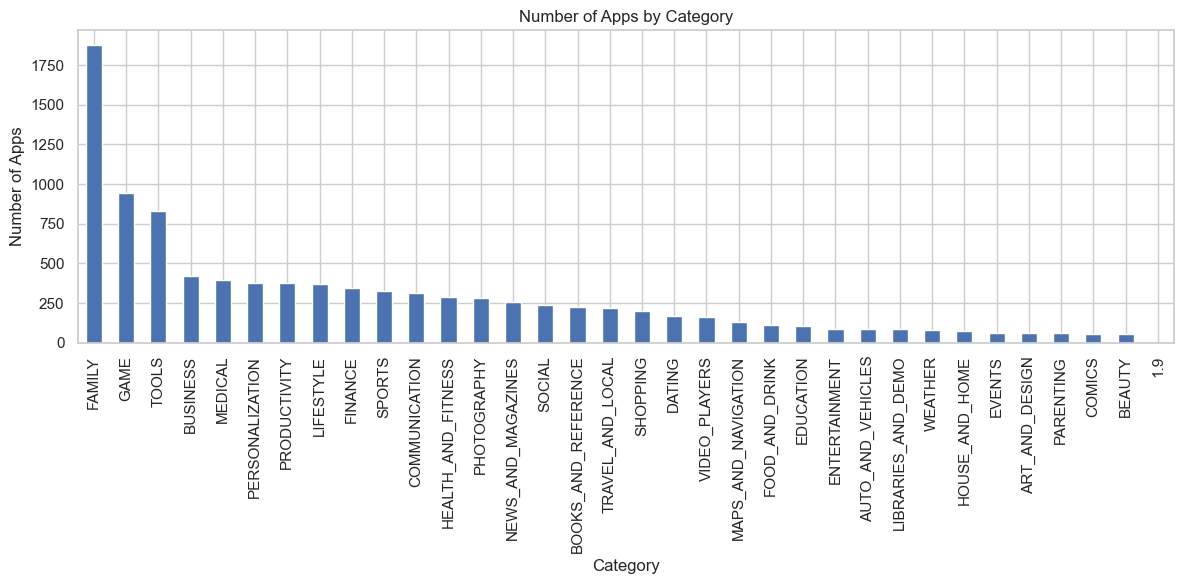

In [33]:
plt.figure(figsize=(12,6))

category_counts.plot(
    kind='bar'
)

plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Top 10 Categories

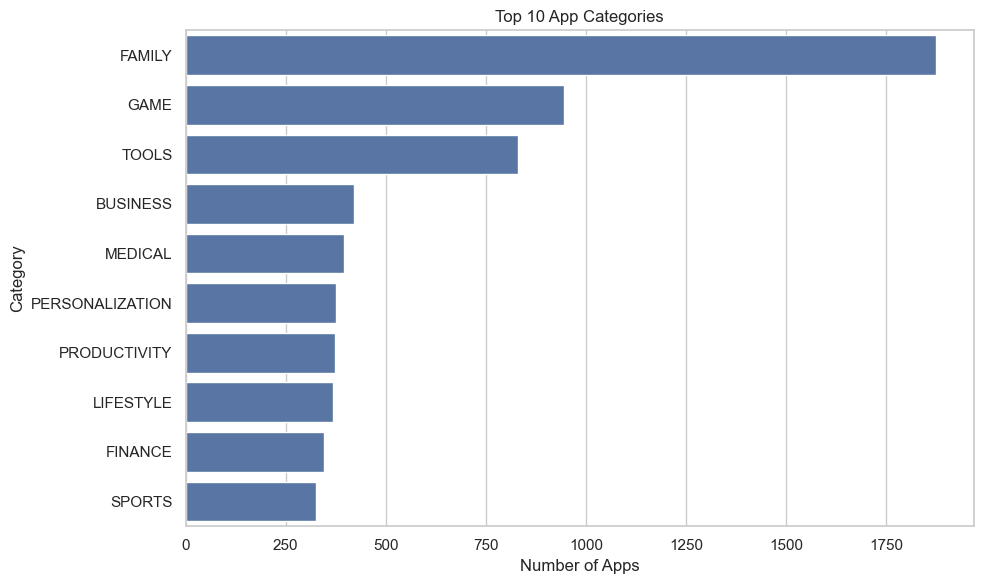

In [34]:
top_categories = apps['Category'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title('Top 10 App Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

Rating Distribution

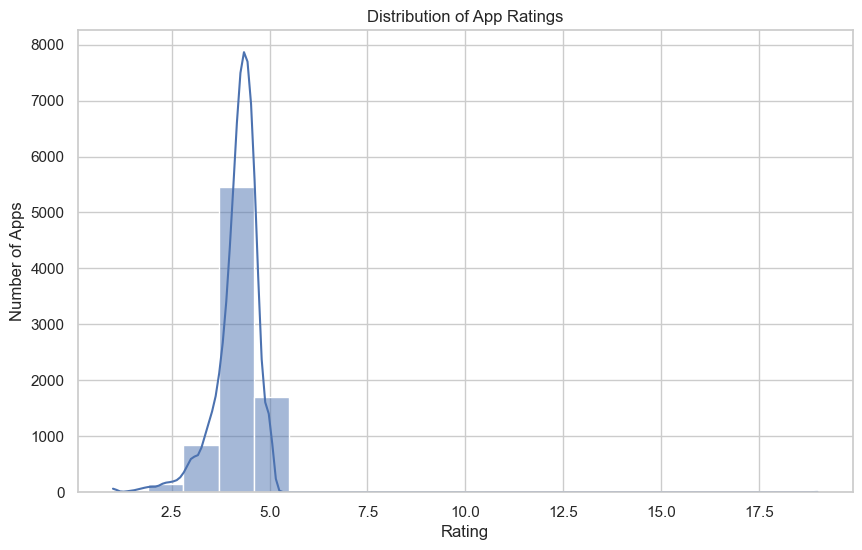

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    apps['Rating'].dropna(),
    bins=20,
    kde=True
)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

Avg Rating by Category

In [36]:
category_rating = (
    apps.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print(category_rating)

Category
1.9                    19.000000
EVENTS                  4.435556
ART_AND_DESIGN          4.359322
EDUCATION               4.354717
BOOKS_AND_REFERENCE     4.344970
PERSONALIZATION         4.332215
PARENTING               4.300000
BEAUTY                  4.278571
SOCIAL                  4.247291
GAME                    4.244432
WEATHER                 4.243056
HEALTH_AND_FITNESS      4.243033
SHOPPING                4.230556
SPORTS                  4.216154
AUTO_AND_VEHICLES       4.190411
FAMILY                  4.183576
PRODUCTIVITY            4.183389
COMICS                  4.181481
LIBRARIES_AND_DEMO      4.178125
FOOD_AND_DRINK          4.171277
MEDICAL                 4.165862
PHOTOGRAPHY             4.155894
HOUSE_AND_HOME          4.140984
ENTERTAINMENT           4.129885
NEWS_AND_MAGAZINES      4.121569
COMMUNICATION           4.121484
FINANCE                 4.115563
BUSINESS                4.098479
LIFESTYLE               4.093355
TRAVEL_AND_LOCAL        4.069519
V

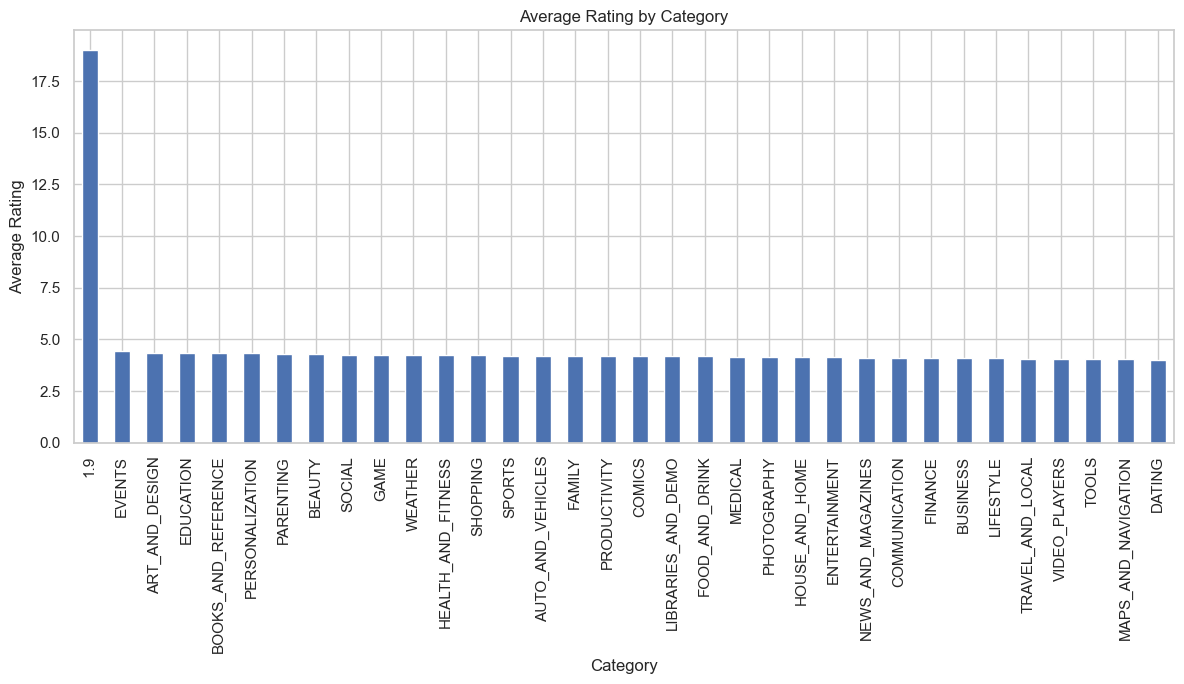

In [37]:
plt.figure(figsize=(12,7))

category_rating.plot(
    kind='bar'
)

plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Top Rated Apps

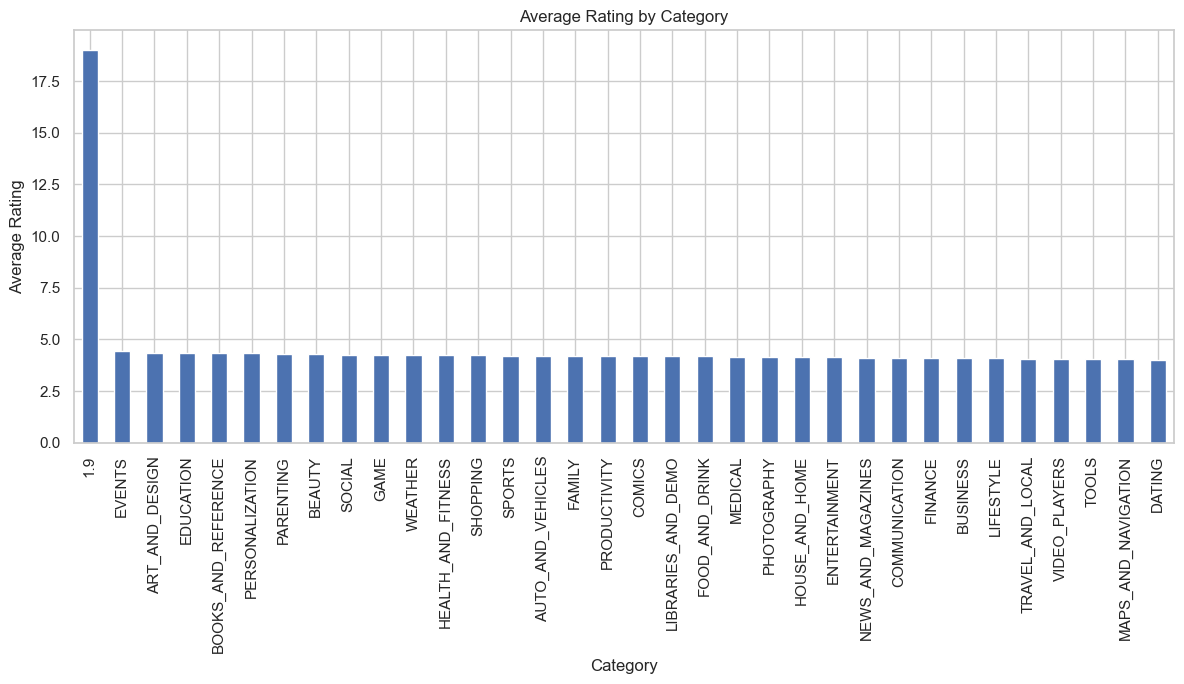

In [38]:
plt.figure(figsize=(12,7))

category_rating.plot(
    kind='bar'
)

plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Most Reviewed Apps

In [39]:
most_reviewed = (
    apps.sort_values(
        'Reviews',
        ascending=False
    )
    [['App', 'Category', 'Rating', 'Reviews', 'Installs']]
    .head(20)
)

display(most_reviewed)

,App,Category,Rating,Reviews,Installs
0,Facebook,SOCIAL,4.1,78158306.0,1.000000e+09
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316.0,1.000000e+09
2,Instagram,SOCIAL,4.5,66577446.0,1.000000e+09
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578.0,1.000000e+09
4,Clash of Clans,GAME,4.6,44893888.0,1.000000e+08
5,Clean Master- Space Cleaner & Antivirus,TOOLS,4.7,42916526.0,5.000000e+08
6,Subway Surfers,GAME,4.5,27725352.0,1.000000e+09
7,YouTube,VIDEO_PLAYERS,4.3,25655305.0,1.000000e+09
8,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.7,24900999.0,5.000000e+08
9,Clash Royale,GAME,4.6,23136735.0,1.000000e+08


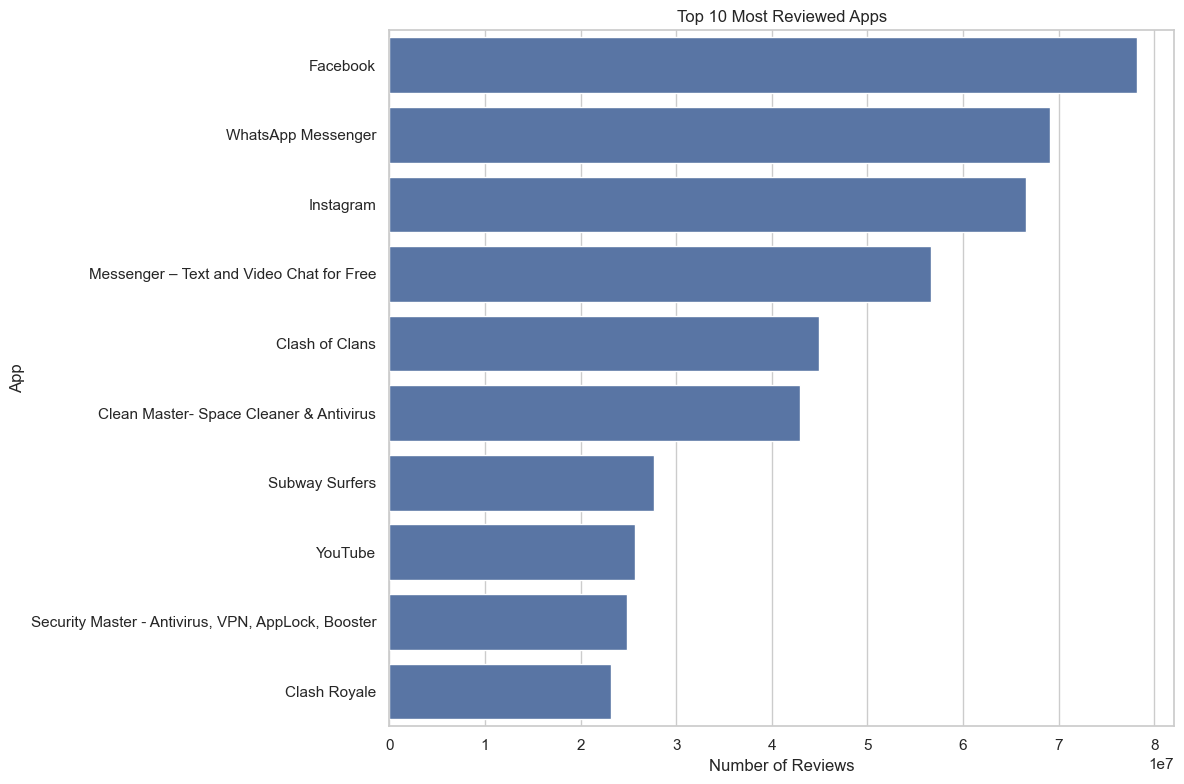

In [40]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=most_reviewed.head(10),
    x='Reviews',
    y='App'
)

plt.title('Top 10 Most Reviewed Apps')
plt.xlabel('Number of Reviews')
plt.ylabel('App')

plt.tight_layout()
plt.show()

Most Installed Apps

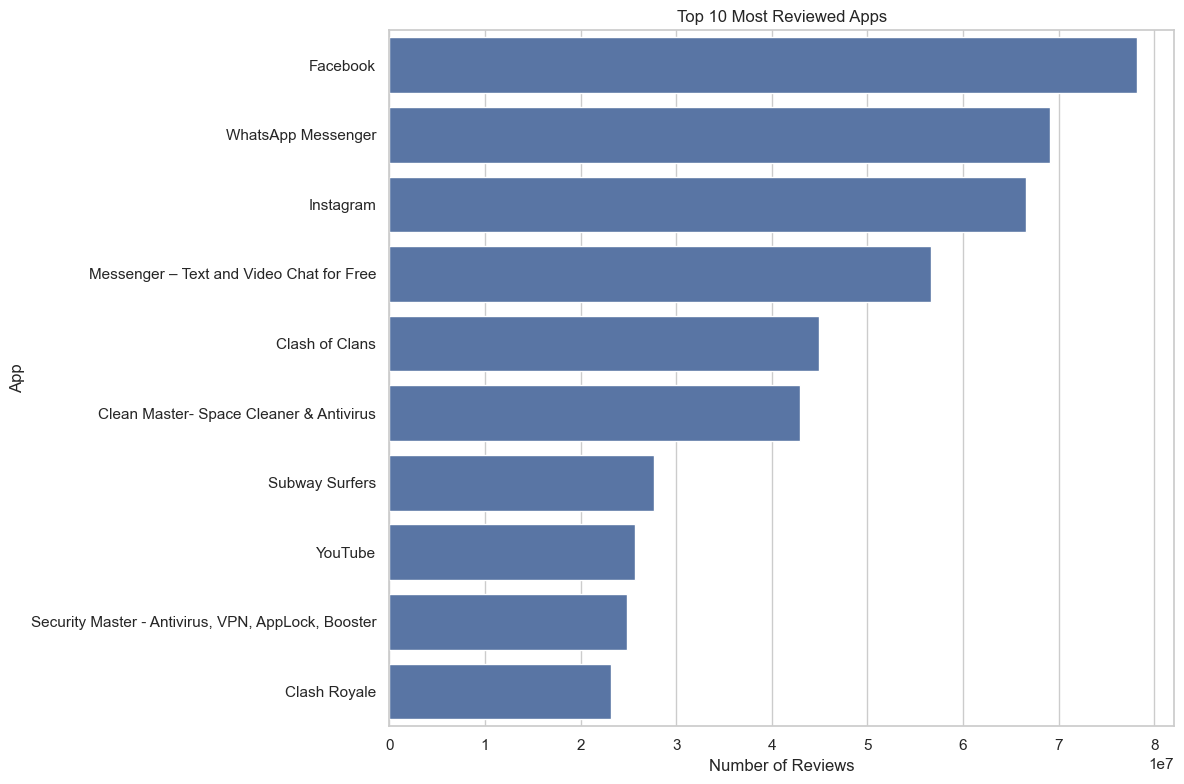

In [41]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=most_reviewed.head(10),
    x='Reviews',
    y='App'
)

plt.title('Top 10 Most Reviewed Apps')
plt.xlabel('Number of Reviews')
plt.ylabel('App')

plt.tight_layout()
plt.show()

Most Installed Apps

In [43]:
# Step 27 — Most Installed Apps

# Create the most_installed dataframe
most_installed = (
    apps.sort_values(
        'Installs',
        ascending=False
    )
    [['App', 'Category', 'Rating', 'Reviews', 'Installs']]
    .head(20)
)

# Display top 20 apps
display(most_installed)

,App,Category,Rating,Reviews,Installs
0,Facebook,SOCIAL,4.1,78158306.0,1.000000e+09
22,Google Photos,PHOTOGRAPHY,4.5,10859051.0,1.000000e+09
89,Google+,SOCIAL,4.2,4831125.0,1.000000e+09
93,Gmail,COMMUNICATION,4.3,4604483.0,1.000000e+09
188,Google Street View,TRAVEL_AND_LOCAL,4.2,2129707.0,1.000000e+09
377,Google Play Movies & TV,VIDEO_PLAYERS,3.7,906384.0,1.000000e+09
51,Google Play Games,FAMILY,4.3,7168735.0,1.000000e+09
388,Google News,NEWS_AND_MAGAZINES,3.9,878065.0,1.000000e+09
42,Google,TOOLS,4.4,8033493.0,1.000000e+09
123,Hangouts,COMMUNICATION,4.0,3419513.0,1.000000e+09


Free Vs Paid Apps

In [44]:
type_counts = apps['Type'].value_counts()

print(type_counts)

Type
Free    8904
Paid     754
0          1
Name: count, dtype: int64


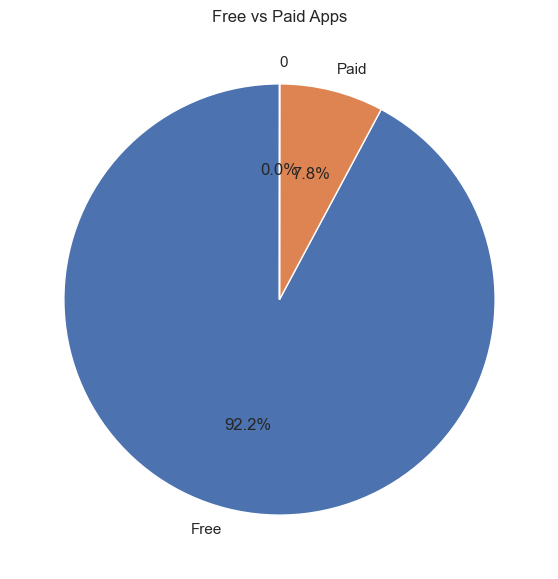

In [45]:
plt.figure(figsize=(7,7))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Free vs Paid Apps')

plt.show()

Free VS Paid Rating

In [46]:
type_rating = (
    apps.groupby('Type')['Rating']
    .mean()
)

print(type_rating)

Type
0       19.000000
Free     4.166223
Paid     4.262126
Name: Rating, dtype: float64


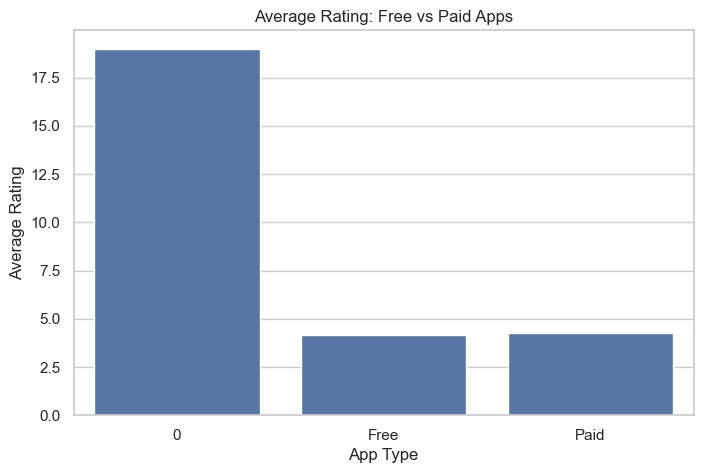

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=type_rating.index,
    y=type_rating.values
)

plt.title('Average Rating: Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Average Rating')

plt.show()

Price Analysis

In [48]:
paid_apps = apps[
    (apps['Type'] == 'Paid') &
    (apps['Price'] > 0)
]

print("Number of paid apps:", len(paid_apps))

Number of paid apps: 754


In [49]:
expensive_apps = (
    paid_apps
    .sort_values('Price', ascending=False)
    [['App', 'Category', 'Price', 'Rating', 'Reviews']]
    .head(20)
)

display(expensive_apps)

,App,Category,Price,Rating,Reviews
5648,I'm Rich - Trump Edition,LIFESTYLE,400.00,3.6,275.0
6373,I am Rich!,FINANCE,399.99,3.8,93.0
8075,most expensive app (H),FAMILY,399.99,4.3,6.0
4441,I Am Rich Premium,FINANCE,399.99,4.1,1867.0
4914,I am Rich Plus,FAMILY,399.99,4.0,856.0
5031,💎 I'm rich,LIFESTYLE,399.99,3.8,718.0
5312,I am rich(premium),FINANCE,399.99,3.5,472.0
5860,I Am Rich Pro,FAMILY,399.99,4.4,201.0
5941,I am Rich,FINANCE,399.99,4.3,180.0
6155,I am rich (Most expensive app),FINANCE,399.99,4.1,129.0


Price Distrubtion

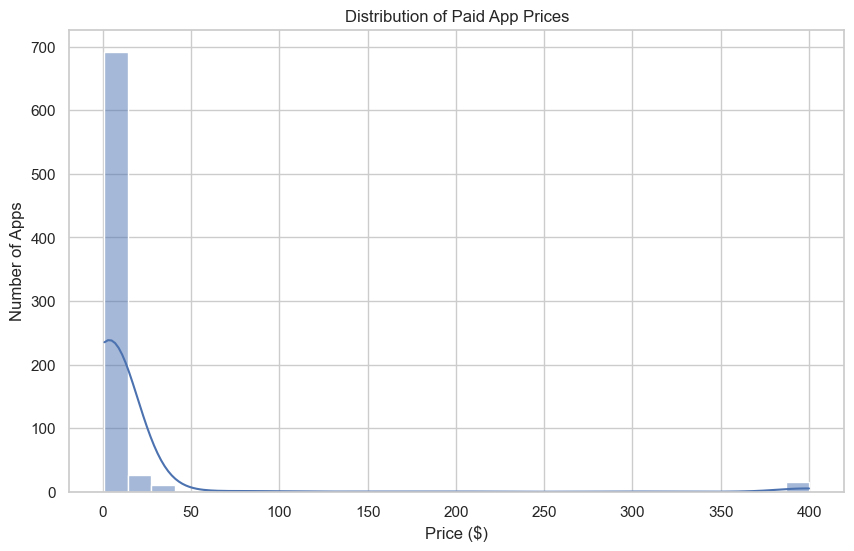

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    paid_apps['Price'],
    bins=30,
    kde=True
)

plt.title('Distribution of Paid App Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

Reviews vs Rating

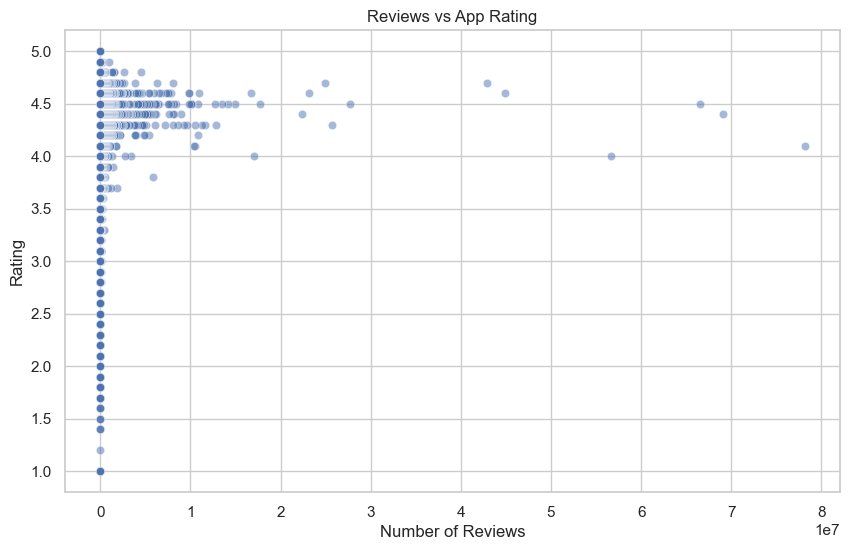

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x='Reviews',
    y='Rating',
    alpha=0.5
)

plt.title('Reviews vs App Rating')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')

plt.show()

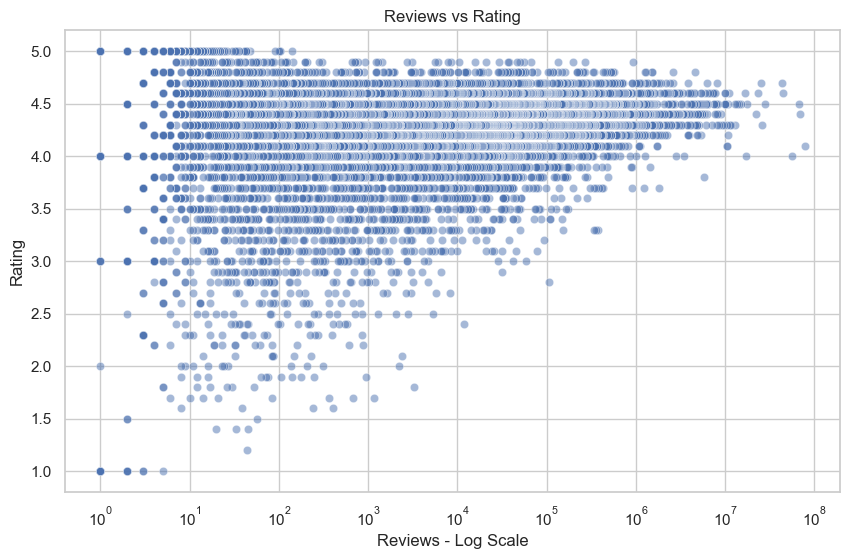

In [52]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x='Reviews',
    y='Rating',
    alpha=0.5
)

plt.xscale('log')

plt.title('Reviews vs Rating')
plt.xlabel('Reviews - Log Scale')
plt.ylabel('Rating')

plt.show()

Install VS Reviews

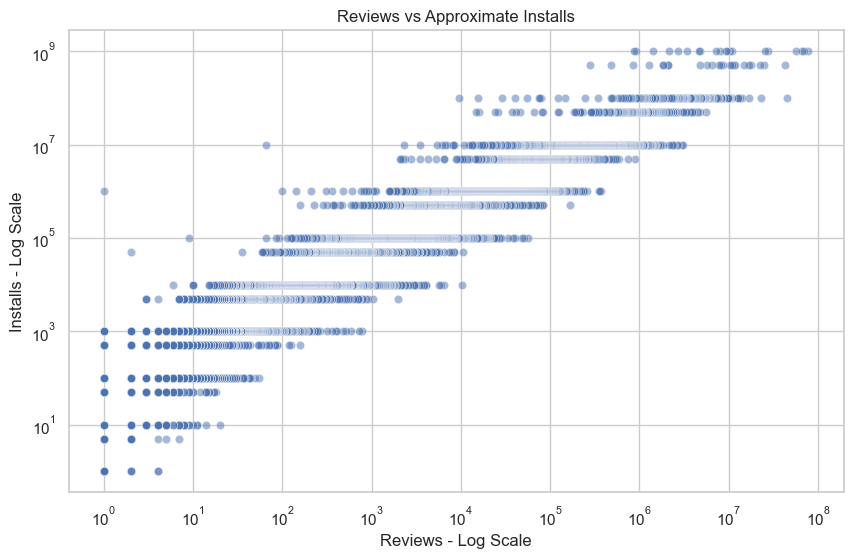

In [53]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x='Reviews',
    y='Installs',
    alpha=0.5
)

plt.xscale('log')
plt.yscale('log')

plt.title('Reviews vs Approximate Installs')
plt.xlabel('Reviews - Log Scale')
plt.ylabel('Installs - Log Scale')

plt.show()

App Size vs Installs

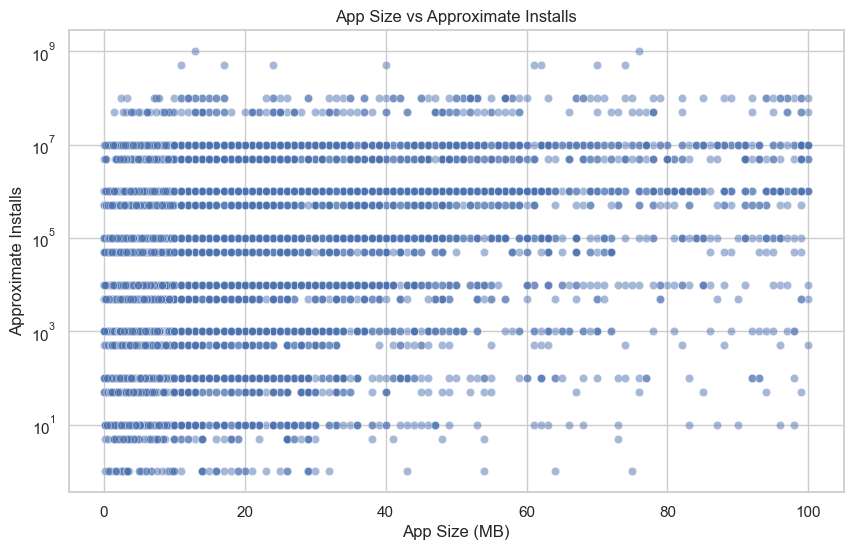

In [54]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps,
    x='Size_MB',
    y='Installs',
    alpha=0.5
)

plt.yscale('log')

plt.title('App Size vs Approximate Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Approximate Installs')

plt.show()

Content Rating Analysis

In [55]:
content_rating = apps['Content Rating'].value_counts()

print(content_rating)

Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Unrated               2
Name: count, dtype: int64


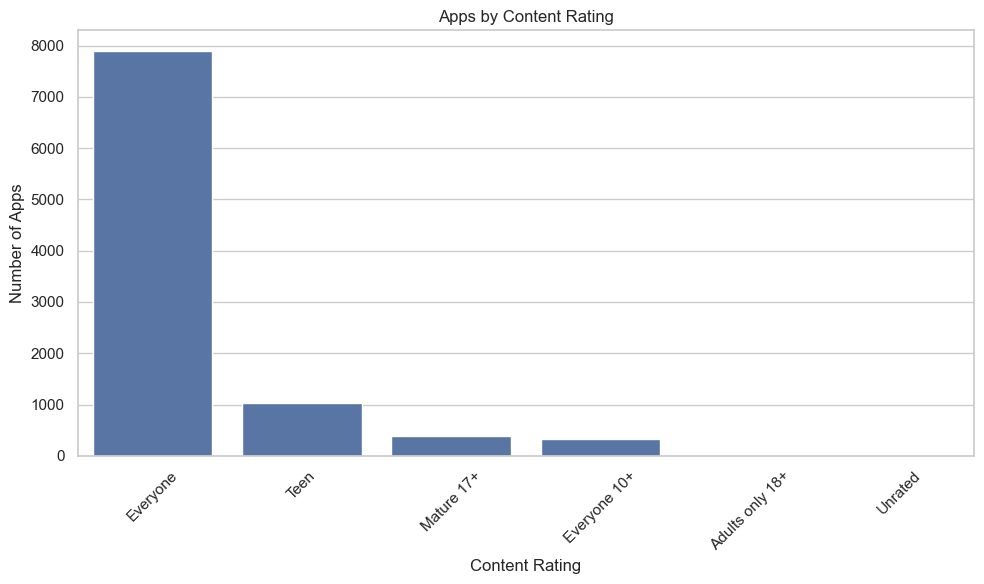

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=content_rating.index,
    y=content_rating.values
)

plt.title('Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Genre Analysis

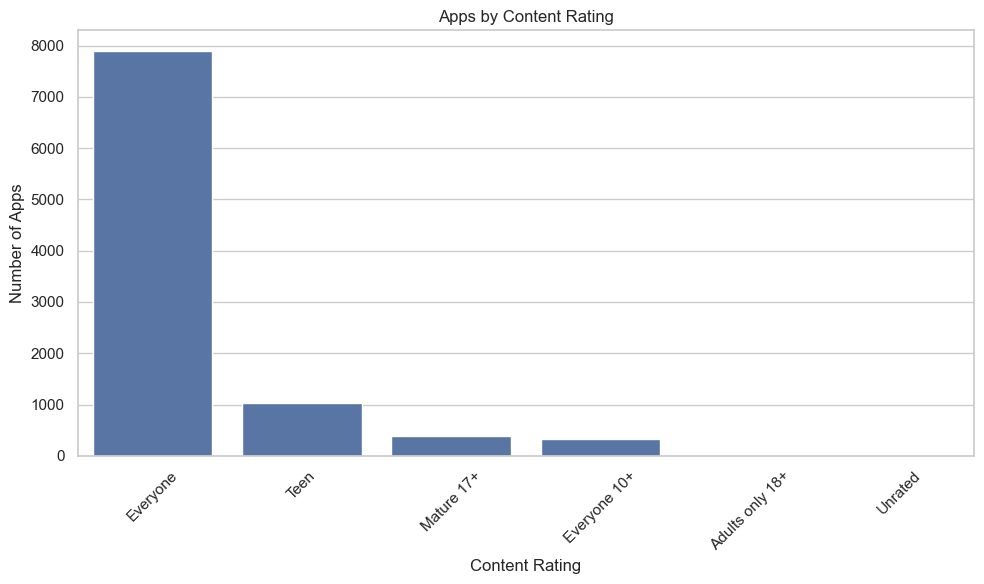

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=content_rating.index,
    y=content_rating.values
)

plt.title('Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Apps by Update Year

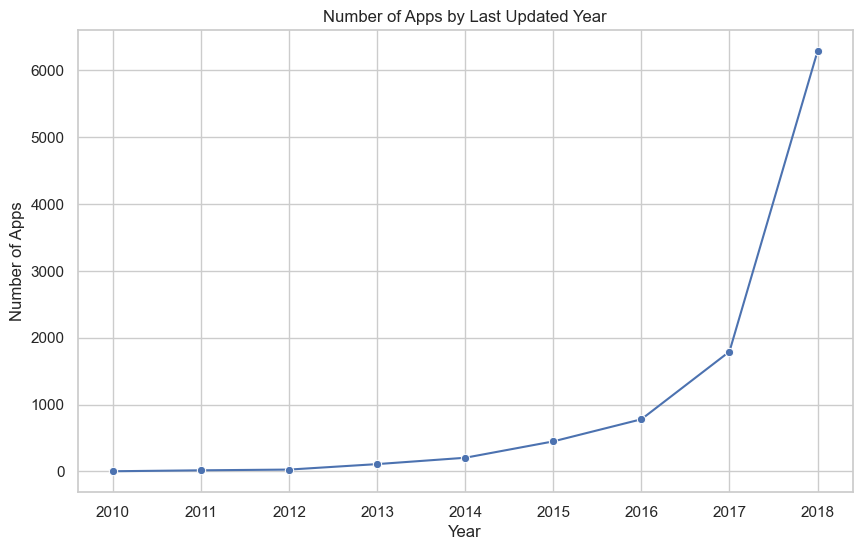

In [58]:
year_counts = apps['Update Year'].value_counts().sort_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o'
)

plt.title('Number of Apps by Last Updated Year')
plt.xlabel('Year')
plt.ylabel('Number of Apps')

plt.show()

Correlations Analysis

In [59]:
numeric_columns = [
    'Rating',
    'Reviews',
    'Installs',
    'Price',
    'Size_MB'
]

correlation_matrix = apps[numeric_columns].corr()

display(correlation_matrix)

,Rating,Reviews,Installs,Price,Size_MB
Rating,1.000000,0.055153,0.040245,-0.021109,0.062958
Reviews,0.055153,1.000000,0.625058,-0.007591,0.179299
Installs,0.040245,0.625058,1.000000,-0.009411,0.134212
Price,-0.021109,-0.007591,-0.009411,1.000000,-0.022367
Size_MB,0.062958,0.179299,0.134212,-0.022367,1.000000


Heat Map

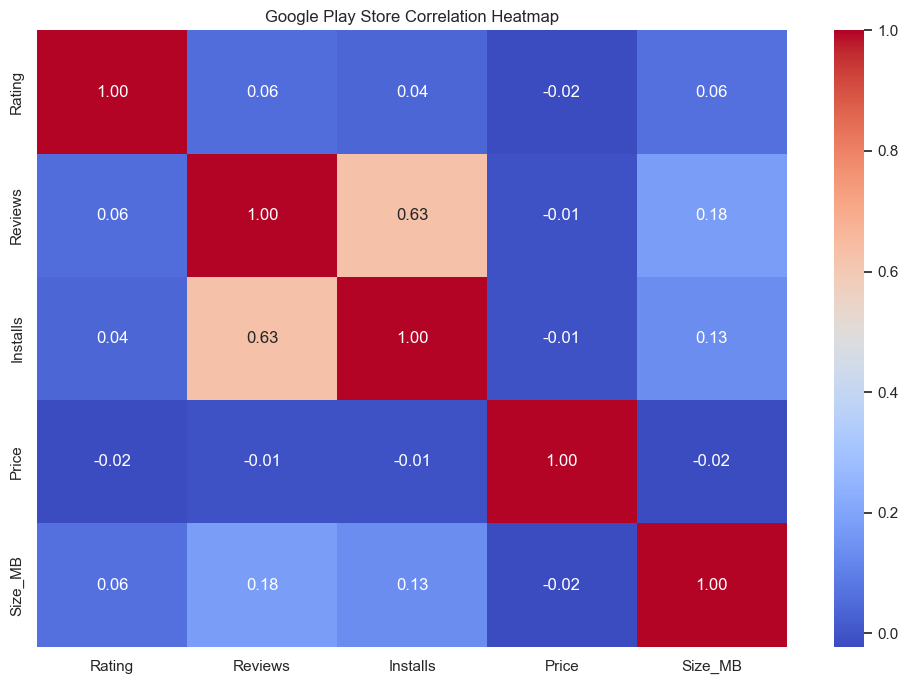

In [60]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Google Play Store Correlation Heatmap')

plt.tight_layout()
plt.show()

User Sentiment Analysis

In [61]:
print(reviews.head())
print(reviews.columns.tolist())

                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


Review Dataset Information

In [62]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


Missing Reviews

In [63]:
print(reviews.isnull().sum())

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


Sentiment Counts

In [64]:
sentiment_counts = reviews['Sentiment'].value_counts()

print(sentiment_counts)

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


Sentiment Visualization

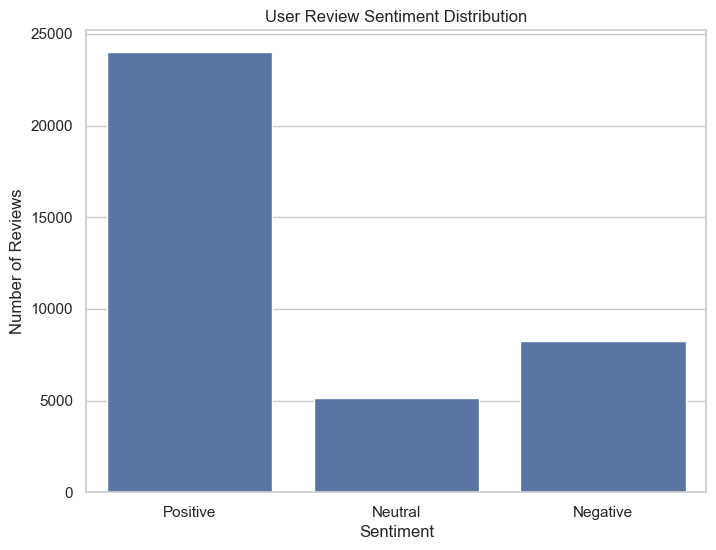

In [65]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=reviews,
    x='Sentiment'
)

plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

Sentiment Percentage

In [66]:
sentiment_percentage = (
    reviews['Sentiment']
    .value_counts(normalize=True) * 100
)

print(sentiment_percentage)

Sentiment
Positive    64.110921
Negative    22.096068
Neutral     13.793011
Name: proportion, dtype: float64


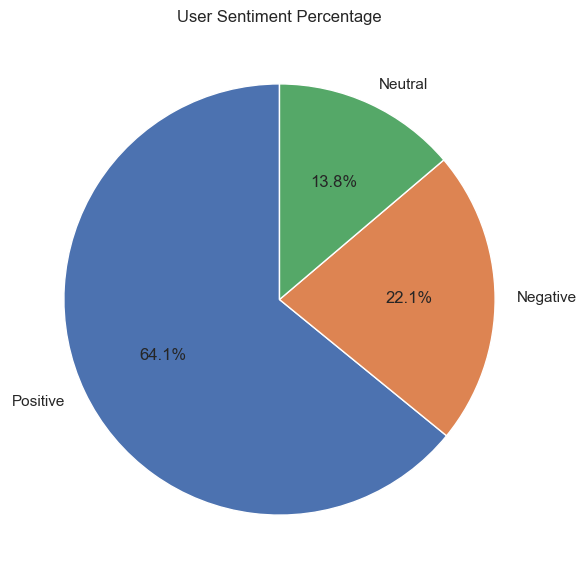

In [67]:
plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('User Sentiment Percentage')

plt.show()

Sentiment Polarity Distribution

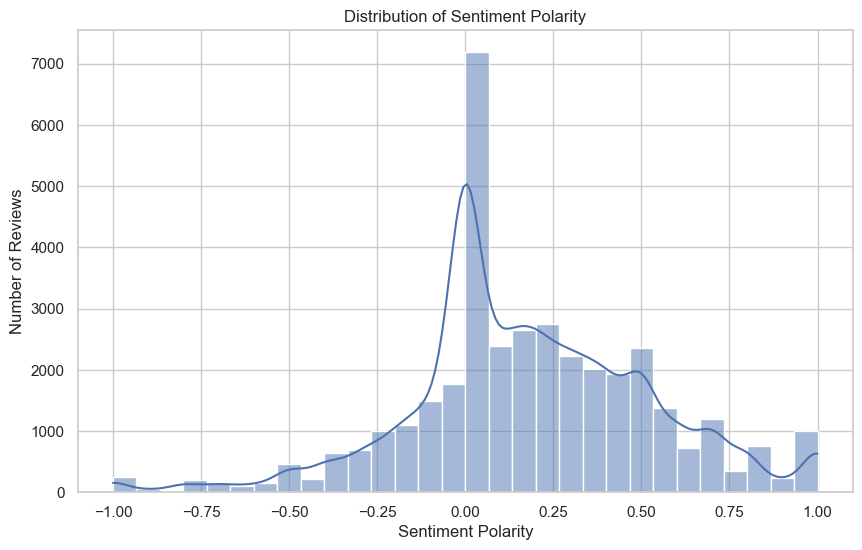

In [68]:
plt.figure(figsize=(10,6))

sns.histplot(
    reviews['Sentiment_Polarity'].dropna(),
    bins=30,
    kde=True
)

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Reviews')

plt.show()

Sentiment Subjectivity

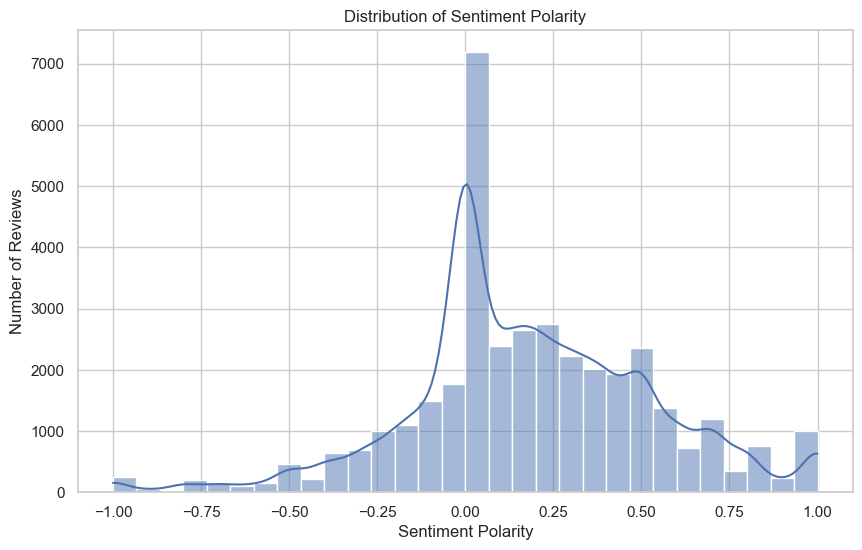

In [69]:
plt.figure(figsize=(10,6))

sns.histplot(
    reviews['Sentiment_Polarity'].dropna(),
    bins=30,
    kde=True
)

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Reviews')

plt.show()

Avg Sentiment Polarity

In [70]:
average_polarity = reviews['Sentiment_Polarity'].mean()

print(
    "Average Sentiment Polarity:",
    round(average_polarity, 3)
)

Average Sentiment Polarity: 0.182


Sentiment By App

In [71]:
sentiment_by_app = (
    reviews.groupby(['App', 'Sentiment'])
    .size()
    .unstack(fill_value=0)
)

display(sentiment_by_app.head())

Sentiment,Negative,Neutral,Positive
App,,,
10 Best Foods for You,10,22,162
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,31
11st,7,10,23
1800 Contacts - Lens Store,6,10,64
1LINE – One Line with One Touch,8,3,27


Apps With Most Positive Reviews

In [72]:
positive_reviews = (
    reviews[reviews['Sentiment'] == 'Positive']
    .groupby('App')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

display(positive_reviews)

App
Helix Jump                        209
Duolingo: Learn Languages Free    200
Calorie Counter - Macros          174
Calorie Counter - MyFitnessPal    169
Bowmasters                        169
10 Best Foods for You             162
Google Photos                     143
8fit Workouts & Meal Planner      137
Garena Free Fire                  136
DRAGON BALL LEGENDS               127
dtype: int64

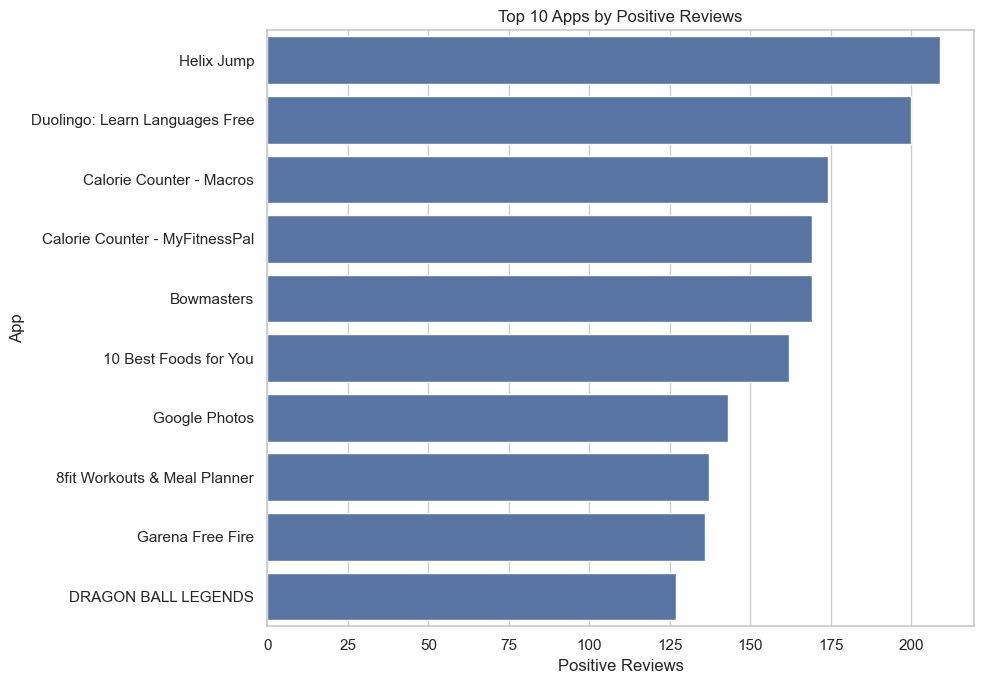

In [73]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=positive_reviews.values,
    y=positive_reviews.index
)

plt.title('Top 10 Apps by Positive Reviews')
plt.xlabel('Positive Reviews')
plt.ylabel('App')

plt.tight_layout()
plt.show()

Apps With Most Negative Reviews

In [74]:
negative_reviews = (
    reviews[reviews['Sentiment'] == 'Negative']
    .groupby('App')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

display(negative_reviews)

App
Angry Birds Classic      147
Candy Crush Saga         126
Bowmasters               119
8 Ball Pool              106
Candy Crush Soda Saga     96
Garena Free Fire          81
Cooking Fever             79
Alto's Adventure          72
Block Puzzle              71
Agar.io                   66
dtype: int64

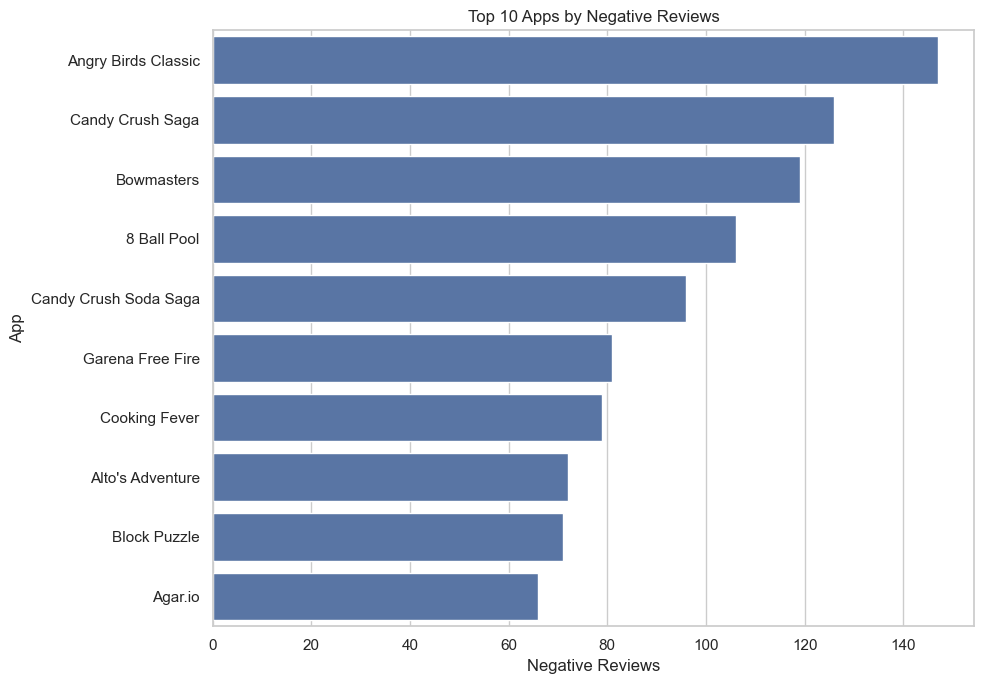

In [75]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=negative_reviews.values,
    y=negative_reviews.index
)

plt.title('Top 10 Apps by Negative Reviews')
plt.xlabel('Negative Reviews')
plt.ylabel('App')

plt.tight_layout()
plt.show()

Avg Sentiment By App

In [76]:
app_sentiment = (
    reviews.groupby('App')['Sentiment_Polarity']
    .mean()
    .sort_values(ascending=False)
)

print("Most positive apps:")
display(app_sentiment.head(10))

print("Most negative apps:")
display(app_sentiment.tail(10))

Most positive apps:


App
HomeWork                                              1.000000
Google Slides                                         0.933333
Daily Workouts - Exercise Fitness Routine Trainer     0.800000
Bed Time Fan - White Noise Sleep Sounds               0.781250
Cameringo Lite. Filters Camera                        0.770269
Google Primer                                         0.750000
GPS Map Free                                          0.700000
GPS Speedometer and Odometer                          0.687500
Best Ovulation Tracker Fertility Calendar App Glow    0.595313
3D Live Neon Weed Launcher                            0.568182
Name: Sentiment_Polarity, dtype: float64

Most negative apps:


App
HOTEL DEALS                                    NaN
HSL - Tickets, route planner and information   NaN
Hangouts Dialer - Call Phones                  NaN
Hemnet                                         NaN
Henry Danger Crime Warp                        NaN
Hiya - Caller ID & Block                       NaN
Hola Launcher- Theme,Wallpaper                 NaN
HomeAway Vacation Rentals                      NaN
Hot or Not - Find someone right now            NaN
Houzz Interior Design Ideas                    NaN
Name: Sentiment_Polarity, dtype: float64

Merge Apps +  Reviews

In [77]:
merged = pd.merge(
    reviews,
    apps[
        [
            'App',
            'Category',
            'Rating',
            'Installs',
            'Type'
        ]
    ],
    on='App',
    how='left'
)

print("Merged dataset shape:")
print(merged.shape)

display(merged.head())

Merged dataset shape:
(64295, 9)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category,Rating,Installs,Type
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS,4.0,500000.0,Free
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS,4.0,500000.0,Free
2,10 Best Foods for You,NaN,NaN,NaN,NaN,HEALTH_AND_FITNESS,4.0,500000.0,Free
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,HEALTH_AND_FITNESS,4.0,500000.0,Free
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,HEALTH_AND_FITNESS,4.0,500000.0,Free


Sentiment By Category

In [78]:
category_sentiment = (
    merged.groupby(['Category', 'Sentiment'])
    .size()
    .unstack(fill_value=0)
)

display(category_sentiment.head())

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,47,58,233
AUTO_AND_VEHICLES,17,36,236
BEAUTY,65,88,185
BOOKS_AND_REFERENCE,95,108,448
BUSINESS,169,258,655


Positive/Negative Sentiment by Category

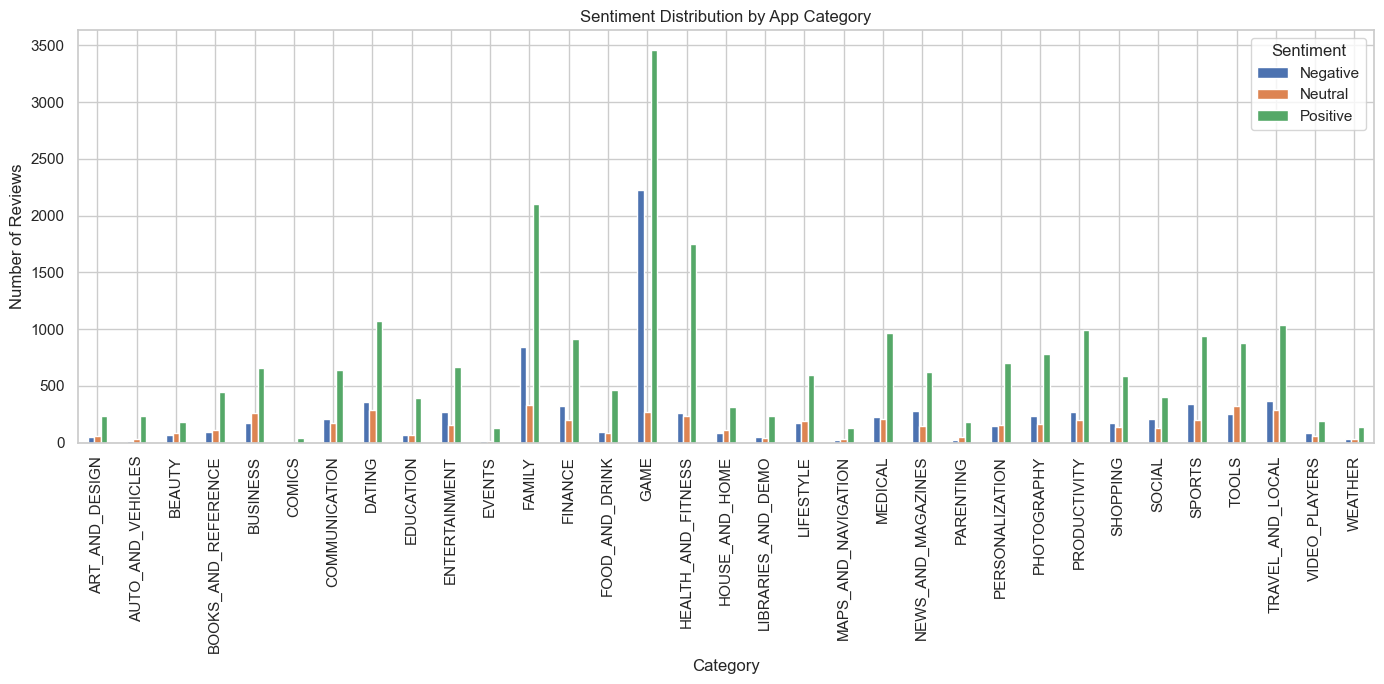

In [79]:
category_sentiment.plot(
    kind='bar',
    figsize=(14,7)
)

plt.title('Sentiment Distribution by App Category')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Average Sentiment by Category

In [80]:
avg_category_sentiment = (
    merged.groupby('Category')['Sentiment_Polarity']
    .mean()
    .sort_values(ascending=False)
)

display(avg_category_sentiment)

Category
COMICS                 0.440031
EVENTS                 0.377933
AUTO_AND_VEHICLES      0.348683
PARENTING              0.318880
EDUCATION              0.296856
WEATHER                0.294978
HEALTH_AND_FITNESS     0.290694
PERSONALIZATION        0.278213
MAPS_AND_NAVIGATION    0.267218
FOOD_AND_DRINK         0.266882
BOOKS_AND_REFERENCE    0.248422
ART_AND_DESIGN         0.245420
LIBRARIES_AND_DEMO     0.240771
HOUSE_AND_HOME         0.235704
BUSINESS               0.232189
MEDICAL                0.224071
PHOTOGRAPHY            0.222888
LIFESTYLE              0.215944
TOOLS                  0.214037
SHOPPING               0.196435
TRAVEL_AND_LOCAL       0.194810
BEAUTY                 0.193360
SPORTS                 0.192511
PRODUCTIVITY           0.184225
DATING                 0.178846
COMMUNICATION          0.177275
FINANCE                0.170783
VIDEO_PLAYERS          0.143543
FAMILY                 0.136273
ENTERTAINMENT          0.128679
NEWS_AND_MAGAZINES     0.127736

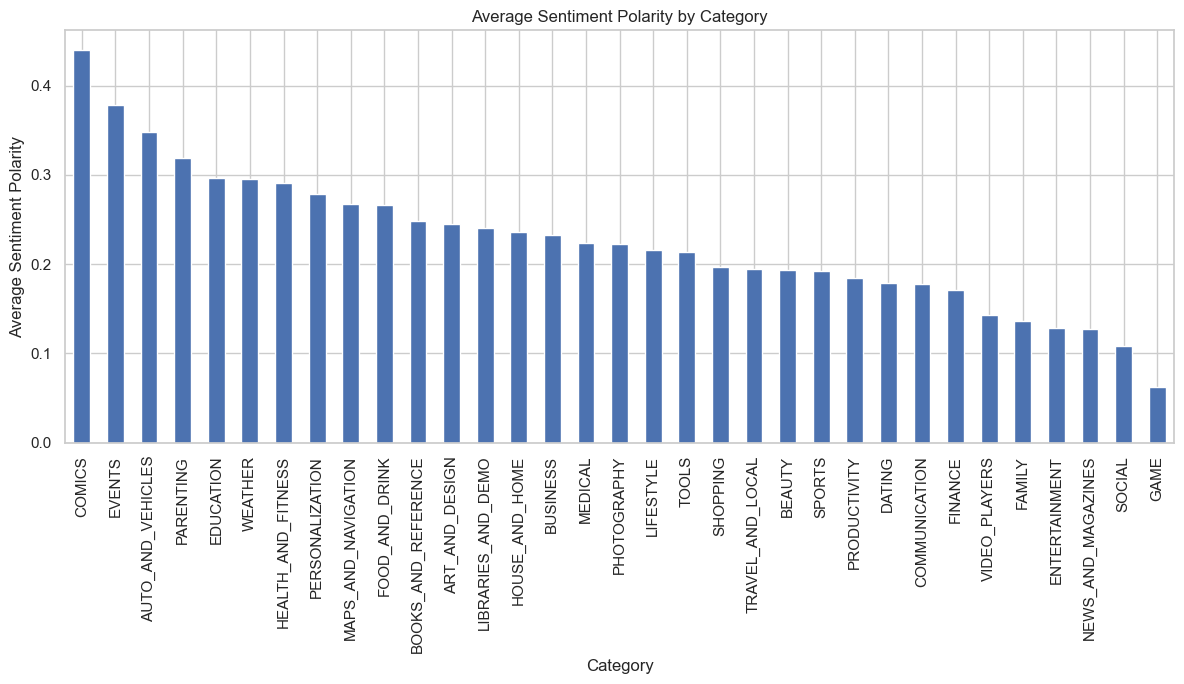

In [81]:
plt.figure(figsize=(12,7))

avg_category_sentiment.plot(
    kind='bar'
)

plt.title('Average Sentiment Polarity by Category')
plt.xlabel('Category')
plt.ylabel('Average Sentiment Polarity')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Sentiment vs App Rating

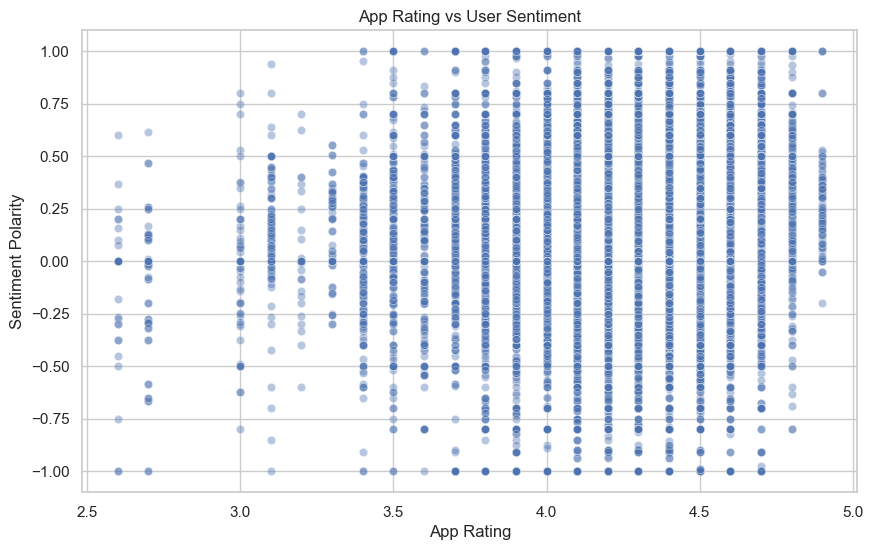

In [82]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x='Rating',
    y='Sentiment_Polarity',
    alpha=0.4
)

plt.title('App Rating vs User Sentiment')
plt.xlabel('App Rating')
plt.ylabel('Sentiment Polarity')

plt.show()

Correlation Between Rating and Sentiment

In [83]:
sentiment_rating_corr = merged[
    ['Rating', 'Sentiment_Polarity']
].corr()

display(sentiment_rating_corr)

,Rating,Sentiment_Polarity
Rating,1.000000,0.092531
Sentiment_Polarity,0.092531,1.000000


Top Negative Reviews

In [84]:
negative_review_text = reviews[
    reviews['Sentiment'] == 'Negative'
][
    ['App', 'Translated_Review', 'Sentiment_Polarity']
].sort_values(
    'Sentiment_Polarity'
)

display(negative_review_text.head(20))

,App,Translated_Review,Sentiment_Polarity
29668,Cougar Dating Life : Date Older Women Sugar Mummy,The worst,-1.0
18983,"BuzzFeed: News, Tasty, Quizzes",Stupid let sign in!!!,-1.0
18943,"BuzzFeed: News, Tasty, Quizzes",Stupid let sign in!!!,-1.0
18604,Build a Bridge!,"Terrible, pay everything",-1.0
3095,ARY NEWS URDU,Worst,-1.0
49191,Free Dating App - Meet Local Singles - Flirt Chat,Rubbish can't even press register worst site ever,-1.0
18596,Build a Bridge!,rip poly bridge terrible controls,-1.0
18485,Buienradar - weer,Very annoying...!,-1.0
17995,Bualuang mBanking,The worst.,-1.0
3151,ASOS,Awful customer automatic responses. The produc...,-1.0


Top Positive Reviews

In [85]:
positive_review_text = reviews[
    reviews['Sentiment'] == 'Positive'
][
    ['App', 'Translated_Review', 'Sentiment_Polarity']
].sort_values(
    'Sentiment_Polarity',
    ascending=False
)

display(positive_review_text.head(20))

,App,Translated_Review,Sentiment_Polarity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,1.0
2293,A+ Mobile,This best bank ever. Don't take word stop A+ F...,1.0
31104,Curso de Ingles Gratis,Excellent material!,1.0
2531,ABC Preschool Free,Excellent,1.0
31110,Curso de Ingles Gratis,It awesome!!!!,1.0
2526,ABC Preschool Free,Really awesome,1.0
31116,Curso de Ingles Gratis,Excellent,1.0
31119,Curso de Ingles Gratis,Excellent,1.0
31420,Cycling - Bike Tracker,Perfect peddle,1.0
31448,"Cymera Camera- Photo Editor, Filter,Collage,La...",Best picture editing,1.0


Business Analysis

# Business Analysis

The analysis focuses on the following business questions:

1. Which app categories contain the largest number of applications?
2. Which categories have the highest average ratings?
3. Which applications have the highest number of reviews?
4. Which applications have the highest approximate installations?
5. What proportion of applications are free and paid?
6. How are paid applications priced?
7. Is there a relationship between reviews and installations?
8. How does app size relate to installations?
9. What is the overall distribution of user sentiment?
10. Which applications receive the most positive reviews?
11. Which applications receive the most negative reviews?
12. Which categories have more positive or negative user feedback?

Automatic Key Insights

In [86]:
print("=" * 60)
print("GOOGLE PLAY STORE ANALYSIS - KEY INSIGHTS")
print("=" * 60)

print("\n1. Total unique apps:", apps['App'].nunique())

print(
    "\n2. Average app rating:",
    round(apps['Rating'].mean(), 2)
)

print(
    "\n3. Most common category:",
    apps['Category'].mode()[0]
)

print(
    "\n4. Most reviewed app:",
    apps.loc[
        apps['Reviews'].idxmax(),
        'App'
    ]
)

print(
    "\n5. Most installed app:",
    apps.loc[
        apps['Installs'].idxmax(),
        'App'
    ]
)

print(
    "\n6. Free apps:",
    (apps['Type'] == 'Free').sum()
)

print(
    "\n7. Paid apps:",
    (apps['Type'] == 'Paid').sum()
)

print(
    "\n8. Average sentiment polarity:",
    round(
        reviews['Sentiment_Polarity'].mean(),
        3
    )
)

print(
    "\n9. Most common sentiment:",
    reviews['Sentiment'].mode()[0]
)

print("\n10. Top category by app count:")
print(apps['Category'].value_counts().head(5))

print("\n11. Sentiment distribution:")
print(reviews['Sentiment'].value_counts())

GOOGLE PLAY STORE ANALYSIS - KEY INSIGHTS

1. Total unique apps: 9660

2. Average app rating: 4.18

3. Most common category: FAMILY

4. Most reviewed app: Facebook

5. Most installed app: Facebook

6. Free apps: 8904

7. Paid apps: 754

8. Average sentiment polarity: 0.182

9. Most common sentiment: Positive

10. Top category by app count:
Category
FAMILY      1875
GAME         945
TOOLS        829
BUSINESS     420
MEDICAL      395
Name: count, dtype: int64

11. Sentiment distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


Final Dashboard-Style Summary

In [87]:
summary = {
    'Total Apps': apps['App'].nunique(),
    'Average Rating': round(apps['Rating'].mean(), 2),
    'Total Reviews': apps['Reviews'].sum(),
    'Free Apps': (apps['Type'] == 'Free').sum(),
    'Paid Apps': (apps['Type'] == 'Paid').sum(),
    'Average Price': round(
        paid_apps['Price'].mean(), 2
    ),
    'Total User Reviews': len(reviews),
    'Average Sentiment Polarity': round(
        reviews['Sentiment_Polarity'].mean(), 3
    )
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=['Metric', 'Value']
)

display(summary_df)

,Metric,Value
0,Total Apps,9.660000e+03
1,Average Rating,4.180000e+00
2,Total Reviews,2.094111e+09
3,Free Apps,8.904000e+03
4,Paid Apps,7.540000e+02
5,Average Price,1.406000e+01
6,Total User Reviews,6.429500e+04
7,Average Sentiment Polarity,1.820000e-01


Final Visualization Dashboard

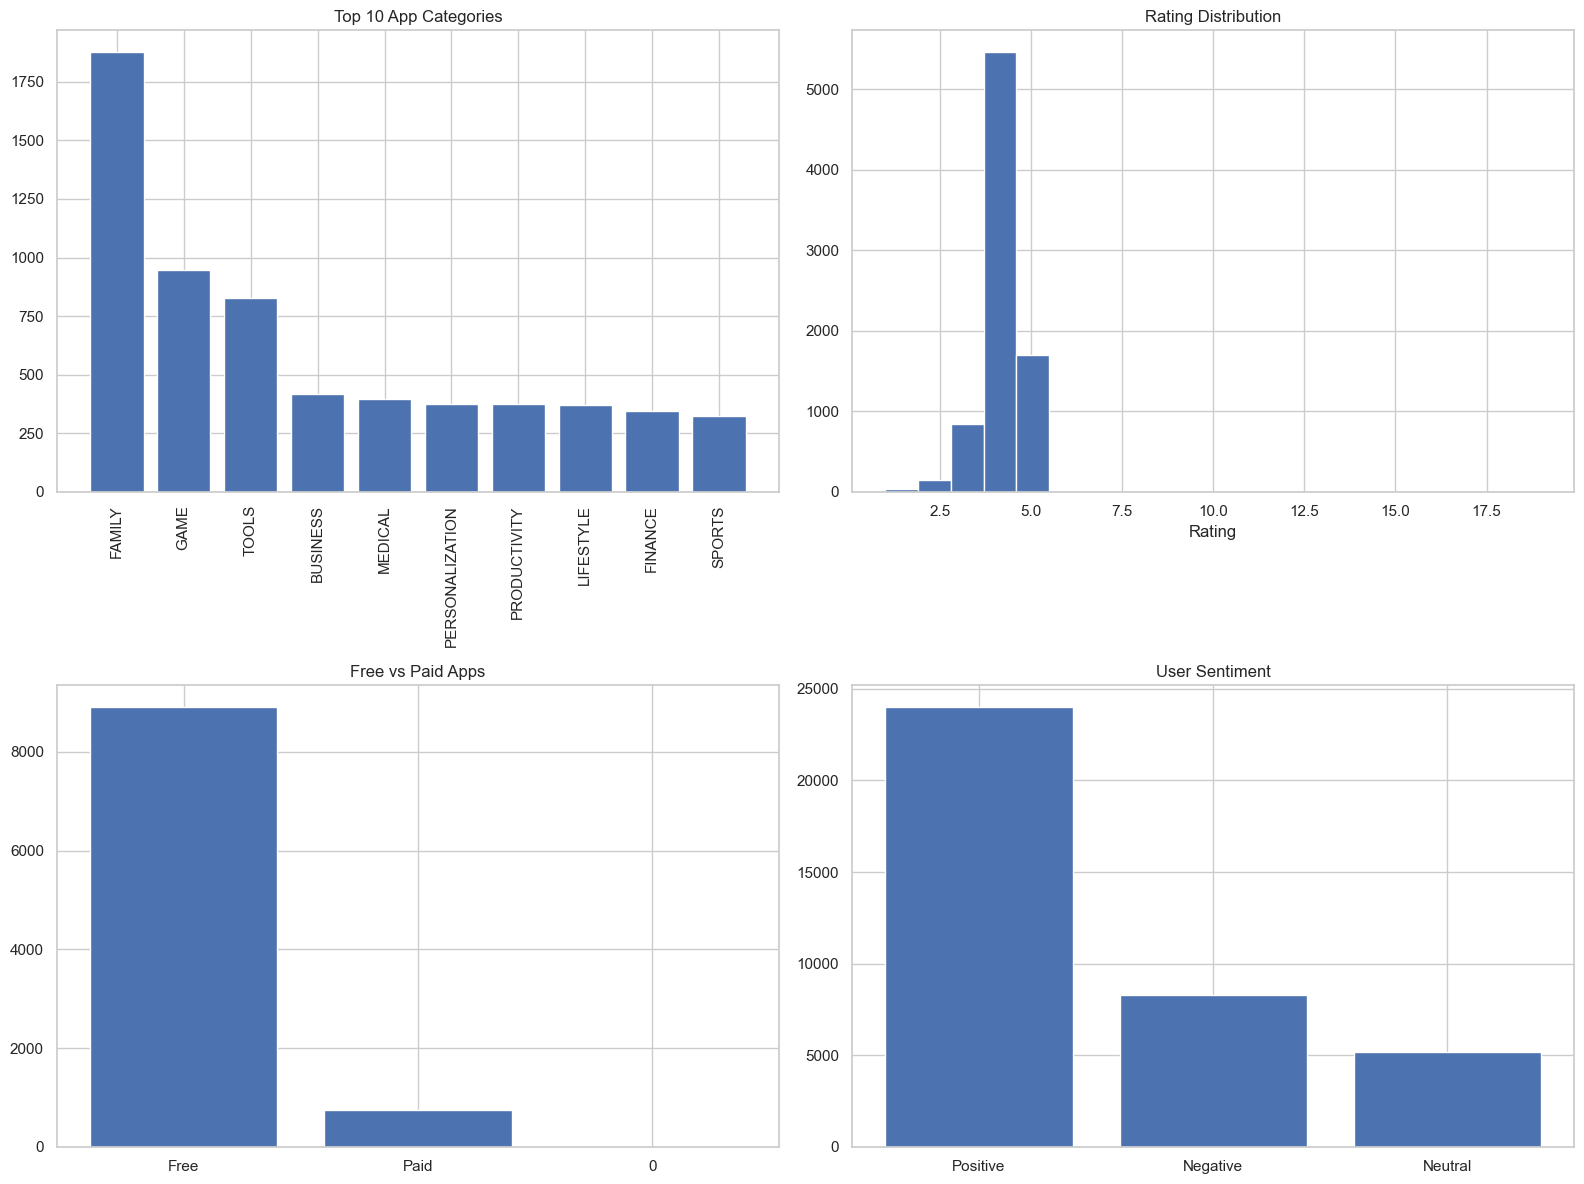

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1. Categories
top_categories = apps['Category'].value_counts().head(10)

axes[0,0].bar(
    top_categories.index,
    top_categories.values
)

axes[0,0].set_title('Top 10 App Categories')
axes[0,0].tick_params(axis='x', rotation=90)

# 2. Rating
axes[0,1].hist(
    apps['Rating'].dropna(),
    bins=20
)

axes[0,1].set_title('Rating Distribution')
axes[0,1].set_xlabel('Rating')

# 3. Free vs Paid
type_counts = apps['Type'].value_counts()

axes[1,0].bar(
    type_counts.index,
    type_counts.values
)

axes[1,0].set_title('Free vs Paid Apps')

# 4. Sentiment
sentiment_counts = reviews['Sentiment'].value_counts()

axes[1,1].bar(
    sentiment_counts.index,
    sentiment_counts.values
)

axes[1,1].set_title('User Sentiment')

plt.tight_layout()
plt.show()

Final Conclusion

# Conclusion

The Google Play Store analysis provides insights into the application
ecosystem by examining app categories, ratings, reviews, installations,
pricing, app size, and user feedback.

The analysis includes:

- Data cleaning and preprocessing
- Missing-value analysis
- Duplicate removal
- Category analysis
- Rating analysis
- Installation analysis
- App size analysis
- Free vs paid comparison
- Price analysis
- Correlation analysis
- User sentiment analysis
- Sentiment polarity analysis
- Category-level sentiment analysis
- Business insights

The results can help understand application popularity, user
satisfaction, pricing patterns, and differences between app categories.